In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons

In [ ]:
X,y = make_moons(n_samples=500,noise=0.05,random_state=42)

In [ ]:
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [ ]:
df.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
WCSS = []
K_range = range(1,11)

In [ ]:
for k in K_range:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(df)
  WCSS.append(kmeans.inertia_)

In [ ]:
WCSS

[501.75086781966905,
 202.42405704705135,
 135.14996263868886,
 87.34061575284268,
 65.29051254377161,
 44.84403134722406,
 35.31213286177549,
 27.091961069414946,
 22.491925102401296,
 19.655835438369795]

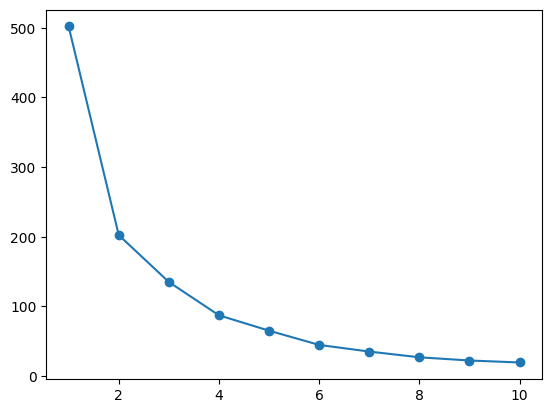

In [ ]:
plt.plot(K_range,WCSS,marker='o')

In [ ]:
k_means_final = KMeans(n_clusters=2,random_state=42)
k_means_final

KMeans(n_clusters=2, random_state=42)

In [ ]:
clusters_final = k_means_final.fit_predict(X_scaled)

In [ ]:
df['cluster'] = clusters_final

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

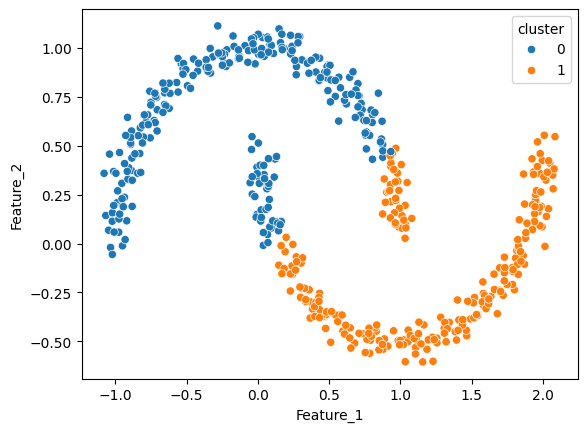

In [ ]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='tab10')

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.5,min_samples=2)
clusters_dbscan = dbscan.fit_predict(X_scaled)

In [ ]:
df['cluster_dbs'] = clusters_dbscan

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

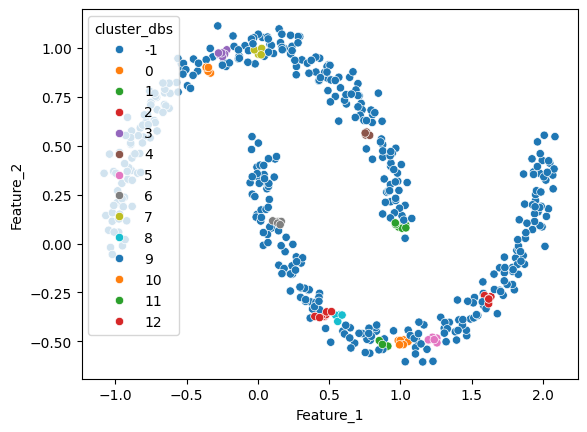

In [ ]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster_dbs'],palette='tab10')